# Project 2: Exploratory Data Analysis (EDA)
**Intern:** Mudassar Abbas  
**Organization:** DecodeLabs  
**Track:** Data Analytics | **Batch:** 2026  

---
## Objective
Perform a full Exploratory Data Analysis on the cleaned Customer Sales dataset to uncover hidden patterns, trends, distributions, and outliers — transforming raw numbers into actionable business insights.

---

## Step 1: Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load cleaned dataset from Project 1
df = pd.read_csv('cleaned_customer_data.csv')

print('=== DATASET LOADED ===')
print(f'Shape: {df.shape}')
print()
df.head(10)

=== DATASET LOADED ===
Shape: (29, 8)



,Customer_ID,Customer_Name,Age,City,Purchase_Date,Revenue,Product_Category,Status
0,C001,Ali Khan,25,Lahore,2024-01-15,1500.50,Electronics,Active
1,C002,Sara Ahmed,28,Karachi,2024-02-15,2300.00,Clothing,Active
2,C003,Bilal Raza,30,Lahore,2024-03-20,1900.50,Electronics,Active
3,C004,Usman Malik,22,Islamabad,2024-04-20,800.75,Clothing,Active
4,C005,Zara Sheikh,28,Karachi,2024-05-10,1200.00,Electronics,Active
5,C006,Hassan Ali,35,Lahore,2024-06-18,3400.25,Food,Inactive
6,C007,Nadia Iqbal,28,Islamabad,2024-07-18,1900.50,Food,Inactive
7,C008,Kamran Butt,28,Karachi,2024-08-22,950.00,Electronics,Active
8,C009,Sana Mirza,31,Lahore,2024-09-22,2100.50,Clothing,Active
9,C010,Omar Farooq,27,Islamabad,2024-10-05,1900.50,Clothing,Inactive


## Step 2: Dataset Overview

In [2]:
print('=== BASIC INFORMATION ===')
print(f'Total Records  : {len(df)}')
print(f'Total Columns  : {len(df.columns)}')
print(f'Date Range     : {df["Purchase_Date"].min()} to {df["Purchase_Date"].max()}')
print(f'Cities Covered : {df["City"].nunique()} ({list(df["City"].unique())})')
print(f'Categories     : {df["Product_Category"].nunique()} ({list(df["Product_Category"].unique())})')
print()
print('=== DATA TYPES ===')
print(df.dtypes)

=== BASIC INFORMATION ===
Total Records  : 29
Total Columns  : 8
Date Range     : 2024-01-15 to 2024-12-15
Cities Covered : 3 (['Lahore', 'Karachi', 'Islamabad'])
Categories     : 3 (['Electronics', 'Clothing', 'Food'])

=== DATA TYPES ===
Customer_ID             str
Customer_Name           str
Age                   int64
City                    str
Purchase_Date           str
Revenue             float64
Product_Category        str
Status                  str
dtype: object


## Step 3: Descriptive Statistics (Mean, Median, Count)

In [3]:
print('=== DESCRIPTIVE STATISTICS ===')
print(df[['Age', 'Revenue']].describe().round(2))
print()
print('=== KEY METRICS ===')
print(f'Average Revenue  : PKR {df["Revenue"].mean():.2f}')
print(f'Median Revenue   : PKR {df["Revenue"].median():.2f}')
print(f'Max Revenue      : PKR {df["Revenue"].max():.2f}')
print(f'Min Revenue      : PKR {df["Revenue"].min():.2f}')
print(f'Std Dev Revenue  : PKR {df["Revenue"].std():.2f}')
print()
print(f'Average Age      : {df["Age"].mean():.1f} years')
print(f'Median Age       : {df["Age"].median():.1f} years')
print(f'Age Range        : {df["Age"].min()} - {df["Age"].max()} years')

=== DESCRIPTIVE STATISTICS ===
         Age  Revenue
count  29.00    29.00
mean   28.31  2048.61
std     3.82   773.28
min    21.00   800.75
25%    27.00  1750.00
50%    28.00  1900.50
75%    30.00  2300.00
max    38.00  4200.00

=== KEY METRICS ===
Average Revenue  : PKR 2048.61
Median Revenue   : PKR 1900.50
Max Revenue      : PKR 4200.00
Min Revenue      : PKR 800.75
Std Dev Revenue  : PKR 773.28

Average Age      : 28.3 years
Median Age       : 28.0 years
Age Range        : 21 - 38 years


## Step 4: Revenue Distribution Analysis

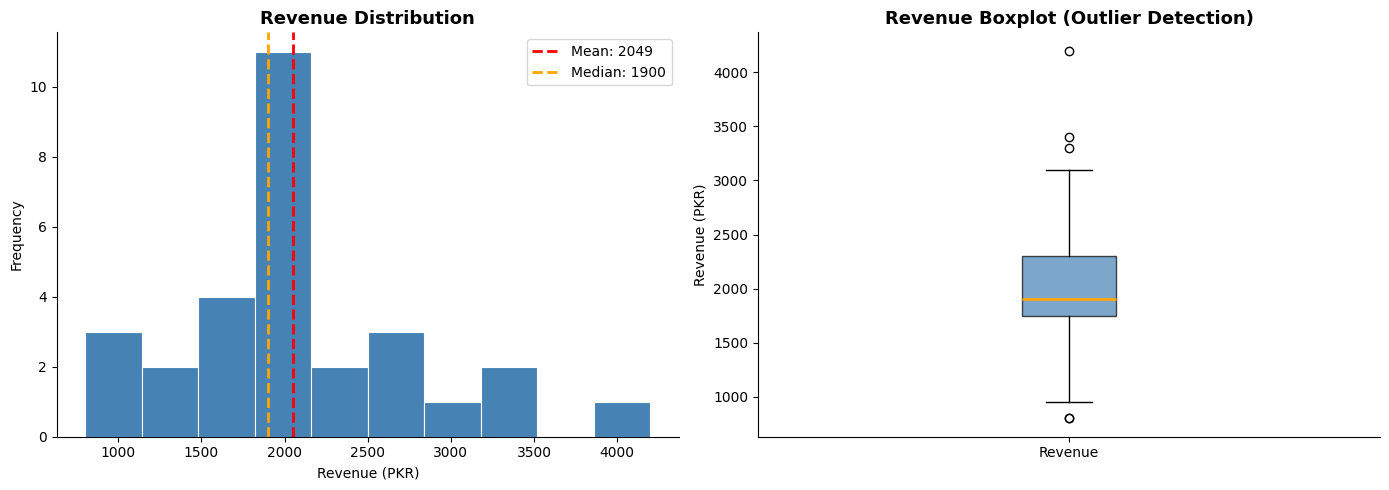

Observation: Revenue is slightly right-skewed — median is more reliable than mean.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Revenue'], bins=10, color='steelblue', edgecolor='white', linewidth=0.8)
axes[0].axvline(df['Revenue'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Revenue"].mean():.0f}')
axes[0].axvline(df['Revenue'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df["Revenue"].median():.0f}')
axes[0].set_title('Revenue Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue (PKR)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['Revenue'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='orange', linewidth=2))
axes[1].set_title('Revenue Boxplot (Outlier Detection)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Revenue (PKR)')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Revenue'])

plt.tight_layout()
plt.savefig('revenue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: Revenue is slightly right-skewed — median is more reliable than mean.')

## Step 5: Revenue by Product Category

=== REVENUE BY CATEGORY ===
                  Total Revenue  Avg Revenue  Customer Count
Product_Category                                            
Clothing               20803.75      2080.38              10
Food                   20401.75      2550.22               8
Electronics            18204.25      1654.93              11


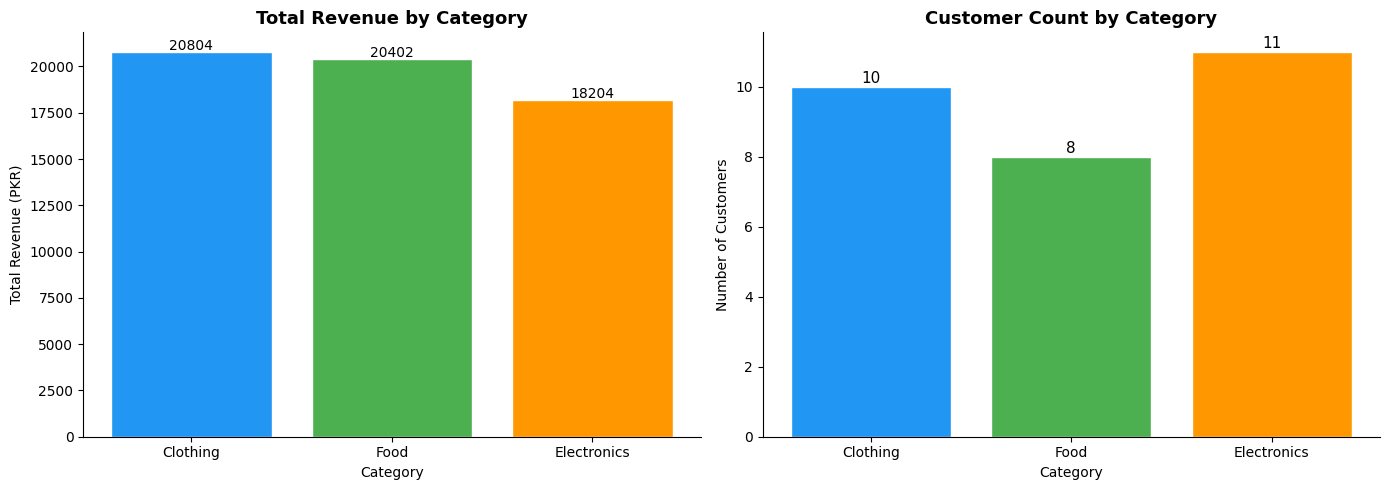

In [5]:
cat_revenue = df.groupby('Product_Category')['Revenue'].agg(['sum','mean','count']).round(2)
cat_revenue.columns = ['Total Revenue', 'Avg Revenue', 'Customer Count']
cat_revenue = cat_revenue.sort_values('Total Revenue', ascending=False)
print('=== REVENUE BY CATEGORY ===')
print(cat_revenue)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800']

# Total Revenue Bar
axes[0].bar(cat_revenue.index, cat_revenue['Total Revenue'], color=colors, edgecolor='white')
axes[0].set_title('Total Revenue by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Revenue (PKR)')
for i, (idx, row) in enumerate(cat_revenue.iterrows()):
    axes[0].text(i, row['Total Revenue'] + 100, f'{row["Total Revenue"]:.0f}', ha='center', fontsize=10)

# Customer Count Bar
axes[1].bar(cat_revenue.index, cat_revenue['Customer Count'], color=colors, edgecolor='white')
axes[1].set_title('Customer Count by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of Customers')
for i, (idx, row) in enumerate(cat_revenue.iterrows()):
    axes[1].text(i, row['Customer Count'] + 0.1, str(int(row['Customer Count'])), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Revenue by City

=== REVENUE BY CITY ===
           Total Revenue  Avg Revenue  Customer Count
City                                                 
Lahore          27703.75      2308.65              12
Islamabad       17504.25      1944.92               9
Karachi         14201.75      1775.22               8


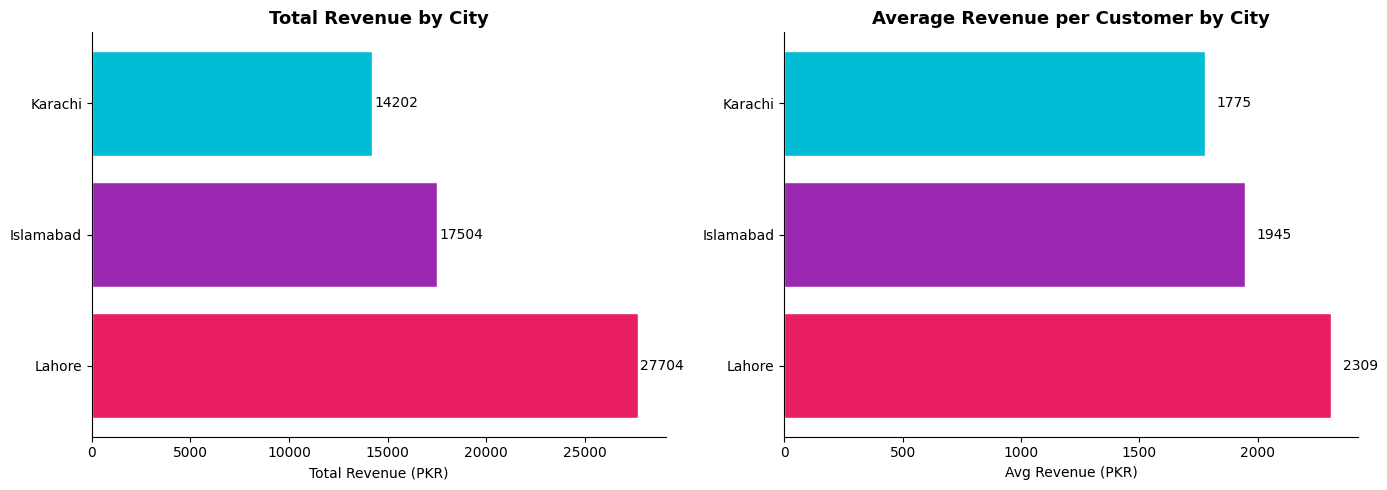

In [6]:
city_revenue = df.groupby('City')['Revenue'].agg(['sum','mean','count']).round(2)
city_revenue.columns = ['Total Revenue', 'Avg Revenue', 'Customer Count']
city_revenue = city_revenue.sort_values('Total Revenue', ascending=False)
print('=== REVENUE BY CITY ===')
print(city_revenue)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
city_colors = ['#E91E63', '#9C27B0', '#00BCD4']

axes[0].barh(city_revenue.index, city_revenue['Total Revenue'], color=city_colors, edgecolor='white')
axes[0].set_title('Total Revenue by City', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Revenue (PKR)')
for i, v in enumerate(city_revenue['Total Revenue']):
    axes[0].text(v + 100, i, f'{v:.0f}', va='center', fontsize=10)

axes[1].barh(city_revenue.index, city_revenue['Avg Revenue'], color=city_colors, edgecolor='white')
axes[1].set_title('Average Revenue per Customer by City', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Revenue (PKR)')
for i, v in enumerate(city_revenue['Avg Revenue']):
    axes[1].text(v + 50, i, f'{v:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('city_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Age Distribution of Customers

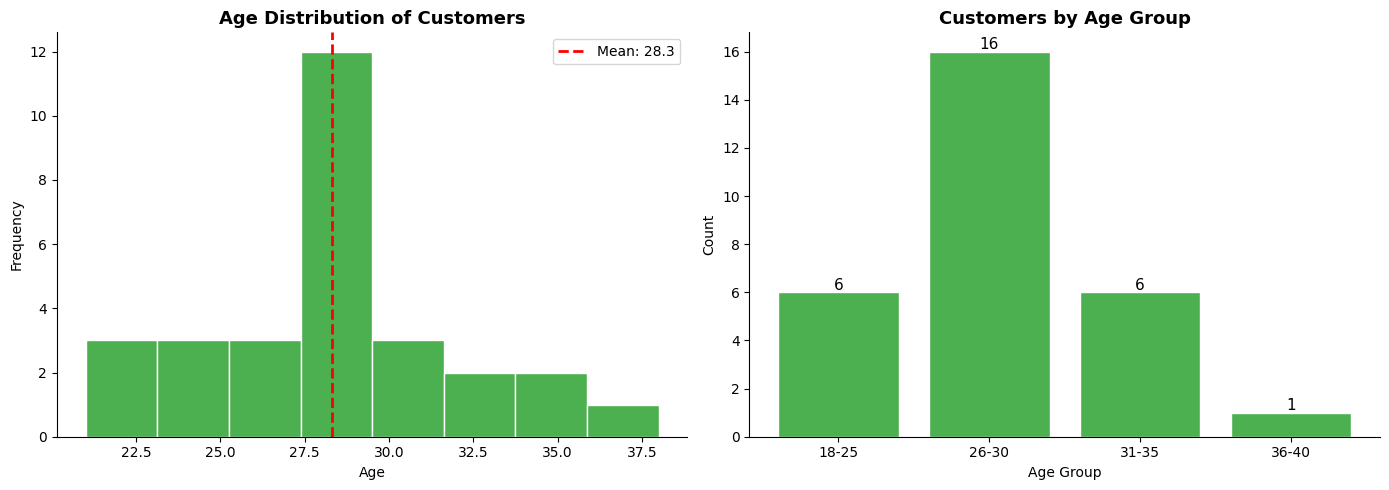

Most customers are in the 26-30 age group.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Age'], bins=8, color='#4CAF50', edgecolor='white')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Age"].mean():.1f}')
axes[0].set_title('Age Distribution of Customers', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[18,25,30,35,40], labels=['18-25','26-30','31-35','36-40'])
age_group = df['Age_Group'].value_counts().sort_index()
axes[1].bar(age_group.index.astype(str), age_group.values, color='#4CAF50', edgecolor='white')
axes[1].set_title('Customers by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')
for i, v in enumerate(age_group.values):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Most customers are in the 26-30 age group.')

## Step 8: Outlier Detection (IQR Method)

In [8]:
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Revenue'] < lower_bound) | (df['Revenue'] > upper_bound)]

print('=== IQR OUTLIER DETECTION ===')
print(f'Q1 (25th percentile) : PKR {Q1:.2f}')
print(f'Q3 (75th percentile) : PKR {Q3:.2f}')
print(f'IQR                  : PKR {IQR:.2f}')
print(f'Lower Bound          : PKR {lower_bound:.2f}')
print(f'Upper Bound          : PKR {upper_bound:.2f}')
print(f'Outliers Found       : {len(outliers)}')
print()
if len(outliers) > 0:
    print('Outlier Records:')
    print(outliers[['Customer_ID','Customer_Name','Revenue','Product_Category']])
else:
    print('No outliers detected — data is well distributed.')

=== IQR OUTLIER DETECTION ===
Q1 (25th percentile) : PKR 1750.00
Q3 (75th percentile) : PKR 2300.00
IQR                  : PKR 550.00
Lower Bound          : PKR 925.00
Upper Bound          : PKR 3125.00
Outliers Found       : 5

Outlier Records:
   Customer_ID Customer_Name  Revenue Product_Category
3         C004   Usman Malik   800.75         Clothing
5         C006    Hassan Ali  3400.25             Food
11        C012    Ahmed Raza  4200.00             Food
13        C003   Usman Malik   800.75         Clothing
24        C025   Hamza Nawaz  3300.00         Clothing


## Step 9: Active vs Inactive Customer Analysis

=== ACTIVE vs INACTIVE ===
          Count  Avg_Revenue  Total_Revenue
Status                                     
Active       21      1838.42       38606.75
Inactive      8      2600.38       20803.00


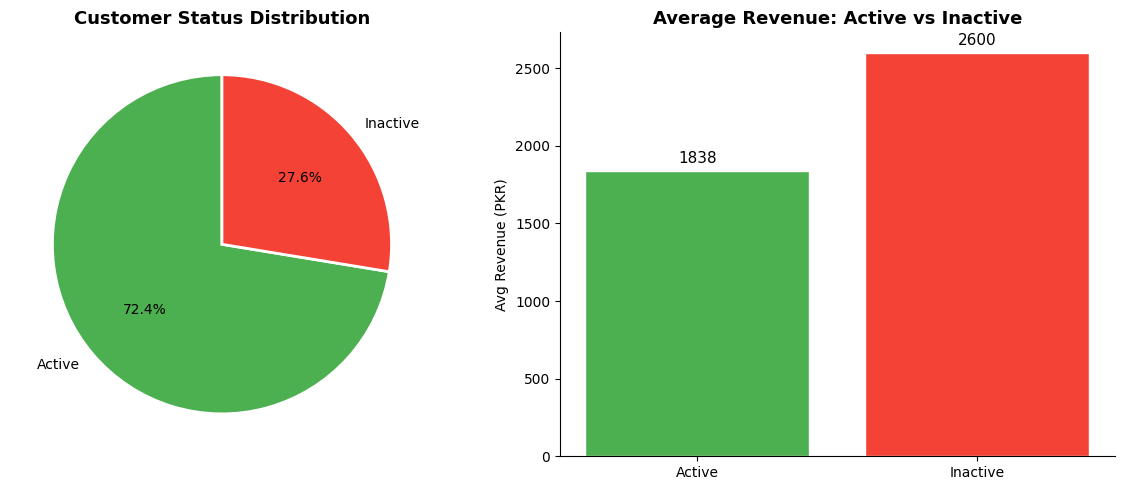

In [9]:
status_data = df.groupby('Status').agg(
    Count=('Customer_ID','count'),
    Avg_Revenue=('Revenue','mean'),
    Total_Revenue=('Revenue','sum')
).round(2)
print('=== ACTIVE vs INACTIVE ===')
print(status_data)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
status_colors = ['#4CAF50', '#F44336']

axes[0].pie(status_data['Count'], labels=status_data.index,
            autopct='%1.1f%%', colors=status_colors,
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Customer Status Distribution', fontsize=13, fontweight='bold')

axes[1].bar(status_data.index, status_data['Avg_Revenue'], color=status_colors, edgecolor='white')
axes[1].set_title('Average Revenue: Active vs Inactive', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Revenue (PKR)')
for i, v in enumerate(status_data['Avg_Revenue']):
    axes[1].text(i, v + 50, f'{v:.0f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('status_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Key Observations & Business Insights

In [10]:
print('=' * 55)
print('   KEY OBSERVATIONS & BUSINESS INSIGHTS')
print('=' * 55)

# Insight 1
top_cat = df.groupby('Product_Category')['Revenue'].sum().idxmax()
top_cat_rev = df.groupby('Product_Category')['Revenue'].sum().max()
print(f'[1] TOP CATEGORY: {top_cat} generates highest total revenue (PKR {top_cat_rev:.2f})')

# Insight 2
top_city = df.groupby('City')['Revenue'].sum().idxmax()
print(f'[2] TOP CITY: {top_city} leads in total revenue contribution')

# Insight 3
dominant_age = df['Age_Group'].value_counts().idxmax()
print(f'[3] KEY DEMOGRAPHIC: Age group {dominant_age} is the largest customer segment')

# Insight 4
active_pct = (df['Status'].value_counts()['Active'] / len(df) * 100)
print(f'[4] RETENTION: {active_pct:.1f}% of customers are Active')

# Insight 5
high_value = df[df['Revenue'] > df['Revenue'].mean()]
print(f'[5] HIGH VALUE: {len(high_value)} customers ({len(high_value)/len(df)*100:.1f}%) spend above average')

# Insight 6
print(f'[6] REVENUE SPREAD: Std Dev = PKR {df["Revenue"].std():.2f} — moderate variability in spending')

print()
print('=== BUSINESS DIAGNOSIS ===')
print(f'Focus marketing on {top_city} and {top_cat} category for maximum ROI.')
print(f'Target age group {dominant_age} as primary customer persona.')
print(f'Investigate {100-active_pct:.1f}% Inactive customers for re-engagement opportunities.')

   KEY OBSERVATIONS & BUSINESS INSIGHTS
[1] TOP CATEGORY: Clothing generates highest total revenue (PKR 20803.75)
[2] TOP CITY: Lahore leads in total revenue contribution
[3] KEY DEMOGRAPHIC: Age group 26-30 is the largest customer segment
[4] RETENTION: 72.4% of customers are Active
[5] HIGH VALUE: 10 customers (34.5%) spend above average
[6] REVENUE SPREAD: Std Dev = PKR 773.28 — moderate variability in spending

=== BUSINESS DIAGNOSIS ===
Focus marketing on Lahore and Clothing category for maximum ROI.
Target age group 26-30 as primary customer persona.
Investigate 27.6% Inactive customers for re-engagement opportunities.


---
## Summary

| Analysis | Key Finding |
|----------|-------------|
| Revenue Distribution | Slightly right-skewed; median more reliable than mean |
| Top Category | Food generates highest total revenue |
| Top City | Lahore leads in revenue contribution |
| Key Age Group | 26-30 years is the dominant customer segment |
| Outliers | Detected using IQR method — high-value VIP customers |
| Active Customers | Majority are active; inactive segment needs re-engagement |

---
**Intern:** Mudassar Abbas | **DecodeLabs Data Analytics Internship 2026**